In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns
import bioframe as bf
import cooler
import cooltools
from pybedtools import BedTool as pbt
from pybedtools.contrib.long_range_interaction import tag_bedpe
from matplotlib.colors import LogNorm
#import bbi
from joblib import Memory
import warnings
from cytoolz import merge
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
from functools import partial
import matplotlib as mpl
from matplotlib.pyplot import figure
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm, TwoSlopeNorm
from matplotlib import ticker
from statannot import add_stat_annotation
from statannotations.Annotator import Annotator


mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family='Helvetica', size=8)
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=8)
mpl.rc('xtick.major', width=0.4, size=8)
mpl.rc('xtick.minor', width=0.4, size=8)
mpl.rc('ytick', labelsize=8)
mpl.rc('ytick.major', width=0.4, size=8)
mpl.rc('ytick.minor', width=0.4, size=8)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('fontTools').setLevel(logging.WARNING)

colors = {'NeuN+': sns.color_palette()[4], 
          'NeuN-': sns.color_palette()[1]}


# Add cache functionality to some functions
cachedir = 'cache'
memory = Memory(cachedir, verbose=0)
eigs_cis_cache = memory.cache(cooltools.eigs_cis)
expected_cis_cache = memory.cache(cooltools.expected_cis, ignore=['nproc'])
saddle_cache = memory.cache(cooltools.saddle)


def k27_hic_signal(k27_df, clr, cvd, view_df, min_sep=200000):
    """
    Get Hi-C values corresponding to h3k27me3 interactions
    1) assign peaks to corresponding hic bins. If more than one peak overlaps a bin, keep longest peak
    2) make all possible pairs out of k27 regions
    3) get corresponding hi-c obs/exp values
    
    k27_df - df with k27 peak coordinates.
    """
    k27_df = k27_df.copy(deep=True)
    if 'length' not in k27_df.columns:
        k27_df['length'] = k27_df['end'] - k27_df['start']
    
    # Convert peak coordinates to corresponding hic bins
    clr_bins = clr.bins()[:]\
                  .dropna(subset=['weight'])[['chrom', 'start', 'end']]
    k27_df_bins = bf.overlap(clr_bins, k27_df, how='inner', suffixes=('_bin', ''))\
                    .drop(columns=['chrom', 'start', 'end'])\
                    .rename(columns={'chrom_bin': 'chrom', 'start_bin': 'start', 'end_bin': 'end'})
    
    # Keep longest peak if multiple are in one bin
    k27_df_bins = k27_df_bins.sort_values(by='length', ascending=False)\
                             .drop_duplicates(subset=['chrom', 'start', 'end'], keep='first')
    
    pair_sites = bf.pair_by_distance(k27_df_bins, min_sep=min_sep, 
                                     max_sep=int(1e10), suffixes=('1', '2'))
    pup = cooltools.pileup(clr, pair_sites, view_df=view_df, 
                           expected_df=cvd, flank=0)
    pup_obs = cooltools.pileup(clr, pair_sites, view_df=view_df, 
                               expected_df=None, flank=0)
    pair_sites['obs_exp'] = pup.flatten()
    pair_sites['obs'] = pup_obs.flatten()
    
    return pair_sites




class MidPointLogNorm(LogNorm):
    """
    Borrowed from: https://stackoverflow.com/questions/48625475/python-shifted-logarithmic-colorbar-white-color-offset-to-center
    """
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        LogNorm.__init__(self,vmin=vmin, vmax=vmax, clip=clip)
        self.midpoint=midpoint
    def __call__(self, value, clip=None):
        result, is_scalar = self.process_value(value)
        x, y = [np.log(self.vmin), np.log(self.midpoint), np.log(self.vmax)], [0, 0.5, 1]
        return np.ma.array(np.interp(np.log(value), x, y), mask=result.mask, copy=False)
    

def saddleplot(
    track,
    saddledata,
    n_bins,
    vrange=None,
    qrange=(0.0, 1.0),
    cmap="coolwarm",
    scale="log",
    vmin=0.5,
    vmax=2,
    color=None,
    title=None,
    xlabel=None,
    ylabel=None,
    clabel=None,
    fig=None,
    fig_kws=None,
    heatmap_kws=None,
    margin_kws=None,
    cbar_kws=None,
    subplot_spec=None,
):
    """
    Function is taken from cooltools package
    Generate a saddle plot.
    Parameters
    ----------
    track : pd.DataFrame
        See cooltools.digitize() for details.
    saddledata : 2D array-like
        Saddle matrix produced by `make_saddle`. It will include 2 flanking
        rows/columns for outlier signal values, thus the shape should be
        `(n+2, n+2)`.
    cmap : str or matplotlib colormap
        Colormap to use for plotting the saddle heatmap
    scale : str
        Color scaling to use for plotting the saddle heatmap: log or linear
    vmin, vmax : float
        Value limits for coloring the saddle heatmap
    color : matplotlib color value
        Face color for margin bar plots
    fig : matplotlib Figure, optional
        Specified figure to plot on. A new figure is created if none is
        provided.
    fig_kws : dict, optional
        Passed on to `plt.Figure()`
    heatmap_kws : dict, optional
        Passed on to `ax.imshow()`
    margin_kws : dict, optional
        Passed on to `ax.bar()` and `ax.barh()`
    cbar_kws : dict, optional
        Passed on to `plt.colorbar()`
    subplot_spec : GridSpec object
        Specify a subregion of a figure to using a GridSpec.
    Returns
    -------
    Dictionary of axes objects.
    """

    track_value_col = track.columns[3]
    track_values = track[track_value_col].values

    digitized_track, binedges = cooltools.digitize(
        track, n_bins, vrange=vrange, qrange=qrange
    )
    x = digitized_track[digitized_track.columns[3]].values.astype(int).copy()
    x = x[(x > -1) & (x < len(binedges) + 1)]

    groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()

    if qrange is not None:
        lo, hi = qrange
        binedges = np.linspace(lo, hi, n_bins + 1)

    # Barplot of mean values and saddledata are flanked by outlier bins
    n = saddledata.shape[0]
    X, Y = np.meshgrid(binedges, binedges)
    C = saddledata
    if (n - n_bins) == 2:
        C = C[1:-1, 1:-1]
        groupmean = groupmean[1:-1]

    # Layout
    if subplot_spec is not None:
        GridSpec = partial(GridSpecFromSubplotSpec, subplot_spec=subplot_spec)
    grid = {}
    gs = GridSpec(
        nrows=3,
        ncols=3,
        width_ratios=[0.15, 1, 0.1],
        height_ratios=[0.15, 1, 0.1],
        wspace=0.05,
        hspace=0.05,
    )

    # Figure
    if fig is None:
        fig_kws_default = dict(figsize=(5, 5))
        fig_kws = merge(fig_kws_default, fig_kws if fig_kws is not None else {})
        fig = plt.figure(**fig_kws)

    # Heatmap
    if scale == "log":
        norm = LogNorm(vmin=vmin, vmax=vmax)
    elif scale == "linear":
        norm = TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)
    else:
        raise ValueError("Only linear and log color scaling is supported")

    grid["ax_heatmap"] = ax = plt.subplot(gs[4])
    heatmap_kws_default = dict(cmap="coolwarm", rasterized=True)
    heatmap_kws = merge(
        heatmap_kws_default, heatmap_kws if heatmap_kws is not None else {}
    )
    img = ax.pcolormesh(X, Y, C, norm=norm, **heatmap_kws)
    plt.gca().yaxis.set_visible(False)
    plt.gca().set_aspect('equal', 'box')

    # Margins
    margin_kws_default = dict(edgecolor="k", facecolor=color, linewidth=0)
    margin_kws = merge(margin_kws_default, margin_kws if margin_kws is not None else {})
    # left margin hist
    grid["ax_margin_y"] = plt.subplot(gs[3], sharey=grid["ax_heatmap"])

    plt.barh(
        binedges, height=1/len(binedges), width=groupmean, align="edge", **margin_kws
    )

    plt.xlim([-1, 1])
    
    plt.ylim(hi, lo)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    # top margin hist
    grid["ax_margin_x"] = plt.subplot(gs[1], sharex=grid["ax_heatmap"])

    plt.bar(
        binedges, width=1/len(binedges), height=groupmean, align="edge", **margin_kws
    )

    plt.xlim(lo, hi)
    plt.ylim([-1, 1])
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().xaxis.set_visible(False)

    # Colorbar
    grid["ax_cbar"] = plt.subplot(gs[5])
    cbar_kws_default = dict(fraction=0.08, label=clabel or "")
    cbar_kws = merge(cbar_kws_default, cbar_kws if cbar_kws is not None else {})
    if scale == "linear" and vmin is not None and vmax is not None:
        grid["cbar"] = cb = plt.colorbar(img, **cbar_kws)
    else:
        grid["cbar"] = cb = plt.colorbar(img, **cbar_kws)
        cb.ax.yaxis.set_major_locator(ticker.FixedLocator([round(vmin, 2), 1, round(vmax, 2)]))
        cb.ax.yaxis.set_minor_locator(ticker.FixedLocator([]))
    

    # extra settings
    grid["ax_heatmap"].set_xlim(lo, hi)
    grid["ax_heatmap"].set_ylim(hi, lo)
    plt.grid(False)
    plt.axis("off")
    if title is not None:
        grid["ax_margin_x"].set_title(title)
    if xlabel is not None:
        grid["ax_heatmap"].set_xlabel(xlabel)
    if ylabel is not None:
        grid["ax_margin_y"].set_ylabel(ylabel)

    return grid, C

def make_chromarms(
    chromsizes,
    midpoints,
    cols_chroms=("chrom", "length"),
    cols_mids=("chrom", "mid"),
    suffixes=("_p", "_q"),
):
    arm_name = []
    chrom_name = []
    chrom_start = []
    chrom_end = []
    chromsizes['mid'] = list(midpoints['mid']) + [0]
    for i, row in chromsizes.iterrows():
        chrom_name = chrom_name + [i]
        chrom_name = chrom_name + [i]
        arm_name = arm_name + [i + suffixes[0]]
        arm_name = arm_name + [i + suffixes[1]]
        chrom_start = chrom_start + [0]
        chrom_start = chrom_start + [row['mid']]
        chrom_end = chrom_end + [row['mid']]
        chrom_end = chrom_end + [row['length']]

    df_chromarms = pd.DataFrame(data = {'chrom' : chrom_name, 'start' : chrom_start, 'end' : chrom_end, 'name': arm_name})
    
    return df_chromarms


hg38_chromsizes = pd.DataFrame(bf.fetch_chromsizes('hg38'))
hg38_cens_sad = bf.fetch_centromeres('hg38')

# create a view with chromosome arms using chromosome sizes and definition of centromeres
hg38_arms = make_chromarms(hg38_chromsizes,  hg38_cens_sad)
hg38_arms = hg38_arms.loc[~hg38_arms['name'].isin(['chr13_p', 'chr14_p', 'chr15_p', 'chr21_p', 
                                                   'chr22_p', 'chrY_p', 'chrY_q', 'chrM_p'])]\
                     .reset_index(drop=True)
hg38_arms.head()

,chrom,start,end,name
0,chr1,0,123400000,chr1_p
1,chr1,123400000,248956422,chr1_q
2,chr2,0,93900000,chr2_p
3,chr2,93900000,242193529,chr2_q
4,chr3,0,90900000,chr3_p


In [55]:
res = 100_000

clr_dir = '../data/'
clr_names = {
            'HC-2Mminus': 'HC-2Mminus.sampled.drop_diag.1kb.mcool',
            'HC24minus': 'HC24minus.sampled.drop_diag.1kb.mcool',
            'HC-91minus': 'HC-91minus.sampled.drop_diag.1kb.mcool',
            'HC-318minus': 'HC-318minus.drop_diag.1kb.mcool',
            'HCM12minus': 'HCM12minus.sampled.drop_diag.1kb.mcool',
            'HC-3Mminus': 'HC-3Mminus.sampled.drop_diag.1kb.mcool',

            'SZ-01minus': 'SZ-01minus.sampled.drop_diag.1kb.mcool',
            'SZ-03minus': 'SZ-03minus.sampled.drop_diag.1kb.mcool',
            'SZ6minus': 'SZ6minus.sampled.drop_diag.1kb.mcool',
            'SZ08minus': 'SZ08minus.sampled.drop_diag.1kb.mcool',
            'SZ10minus': 'SZ10minus.sampled.drop_diag.1kb.mcool',
            'SZ20minus': 'SZ20minus.sampled.drop_diag.1kb.mcool',
}


clrs = {name: cooler.Cooler(clr_dir + clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}

names = list(clrs.keys())
names

['HC-2Mminus',
 'HC24minus',
 'HC-91minus',
 'HC-318minus',
 'HCM12minus',
 'HC-3Mminus',
 'SZ-01minus',
 'SZ-03minus',
 'SZ6minus',
 'SZ08minus',
 'SZ10minus',
 'SZ20minus']

In [56]:
cvd  = {}
name = names[0]
cvd[name] = expected_cis_cache(
                clrs[name],
                view_df=hg38_arms,
                smooth=False,
                nproc=10
            )
eig_df = pd.read_csv(f"schizo_12samples_100k_resolution_results/{name}/{name}_inspectro16_frankenstein_compartments.bed", sep = '\t', header = None, names = ['chrom', 'start', 'end', f'E1.{name}'])

for name in names[1:]:
    cvd[name] = expected_cis_cache(
                clrs[name],
                view_df=hg38_arms,
                smooth=False,
                nproc=10
            )
    eig_df_one = pd.read_csv(f"schizo_12samples_100k_resolution_results/{name}/{name}_inspectro16_frankenstein_compartments.bed", sep = '\t', header = None, names = ['chrom', 'start', 'end', f'E1.{name}'])
    eig_df = eig_df.merge(eig_df_one, on=['chrom', 'start', 'end'], validate="1:1")

# Whole-genome saddle

In [57]:
interaction_sum = {name:{} for name in names}
interaction_count = {name:{} for name in names}

saddle_nbins = 50



for name in names:
    interaction_sum[name], interaction_count[name] = saddle_cache(
                    clrs[name],
                    cvd[name],
                    eig_df[['chrom','start','end', f'E1.{name}']],
                    'cis',
                    n_bins=saddle_nbins,
                    qrange=(0.025, 0.975),
                    view_df=hg38_arms,
                    min_diag=4,
            )

In [58]:

phenotypes = [['HC-2Mminus', 'HC_minus_old', 'old', 'HC'],
                ['HC24minus', 'HC_minus_old', 'old', 'HC'],
                ['HC-91minus', 'HC_minus_old', 'old', 'HC'],
                ['HC-318minus', 'HC_minus_old', 'old', 'HC'],
                ['HCM12minus', 'HC_minus_young', 'young', 'HC'],
                ['HC-3Mminus', 'HC_minus_young', 'young', 'HC'],
                ['SZ-01minus', 'SZ_minus_young', 'young', 'SZ'],
                ['SZ-03minus', 'SZ_minus_old', 'old', 'SZ'],
                ['SZ6minus', 'SZ_minus_old', 'old', 'SZ'],
                ['SZ08minus', 'SZ_minus_old', 'old', 'SZ'],
                ['SZ10minus', 'SZ_minus_old', 'old', 'SZ'],
                ['SZ20minus', 'SZ_minus_young', 'young', 'SZ'],
                       ]

phens = ['HC_minus_old', 'HC_minus_young', 'SZ_minus_old', 'SZ_minus_young']
phens_len = {'HC_minus_old':4, 'HC_minus_young':2, 'SZ_minus_old':4, 'SZ_minus_young':2}


sp ={}
m_neu = {}
eig_df_av = {phen:[] for phen in phens}
for name, phen, age, з in phenotypes:
    m_neu[name] = interaction_sum[name] / interaction_count[name]

for phen in m_neu.keys():
    m_neu[phen] = np.mean(m_neu[phen], axis = 0)




In [59]:
m_neu_av = {phen:np.zeros((saddle_nbins + 2, saddle_nbins+2)) for phen in phens}
eig_df_av = {phen:eig_df[['chrom','start','end', f'E1.HC-2Mminus']] for phen in phens}

for phen in eig_df_av.keys():
    eig_df_av[phen][f'E1.HC-2Mminus'] = np.zeros((len( eig_df_av[phen]['E1.HC-2Mminus'])))
    eig_df_av[phen] = eig_df_av[phen].rename(columns={"E1.HC-2Mminus": f"E1.{phen}"})

/tmp/ipykernel_164041/3169941300.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eig_df_av[phen][f'E1.HC-2Mminus'] = np.zeros((len( eig_df_av[phen]['E1.HC-2Mminus'])))


In [60]:
for name, phen, age, cts in phenotypes:
    print(name, phen)
    m_neu_av[phen] += (interaction_sum[name] / interaction_count[name])/phens_len[phen]
    eig_df_av[phen][f'E1.{phen}'] += eig_df[f'E1.{name}']/phens_len[phen]

HC-2Mminus HC_minus_old
HC24minus HC_minus_old
HC-91minus HC_minus_old
HC-318minus HC_minus_old
HCM12minus HC_minus_young
HC-3Mminus HC_minus_young
SZ-01minus SZ_minus_young
SZ-03minus SZ_minus_old
SZ6minus SZ_minus_old
SZ08minus SZ_minus_old
SZ10minus SZ_minus_old
SZ20minus SZ_minus_young


/tmp/ipykernel_164041/1292147621.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()
/tmp/ipykernel_164041/1292147621.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()


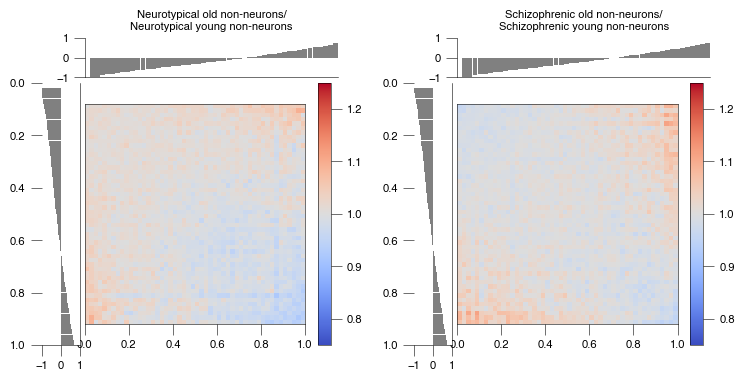

In [70]:
sp ={}

saddle_nbins = 50

d = len(phens)

fig=plt.figure(figsize=(15, 15))
mygs = gridspec.GridSpec(d, d, figure=fig)

ph = [['HC_minus_old', 'HC_minus_young'], ['SZ_minus_old', 'SZ_minus_young']]
naming = {'HC_minus_young' : 'Neurotypical young non-neurons', 'SZ_minus_young': 'Schizophrenic young non-neurons', 'HC_minus_old' : 'Neurotypical old non-neurons', 'SZ_minus_old': 'Schizophrenic old non-neurons'}


for j in range(2):
        name1 = ph[j][0]#phens[i]
        name2 = ph[j][1]#phens[j]
        title = ''
        righttitle=''
    
        title = f'{naming[name1]}/\n{naming[name2]}'
        sp_gs, sp['HC'] =  saddleplot(
            eig_df_av[name1],
            m_neu_av[name1] / m_neu_av[name2],
            title=title,
            scale='linear',
            vmin=0.75, vmax=1.25,
            margin_kws={'facecolor': 'grey'},
            subplot_spec=mygs[i, j],
            fig=fig,
            n_bins=50)

plt.tight_layout()
#plt.savefig(f"picture_results/saddle_ratio.aging.all_against_all_12samples_non-neurons.svg",bbox_inches='tight')

In [64]:
ratio_hc = m_neu_av['HC_minus_old'] / m_neu_av['HC_minus_young']
ratio_sz = m_neu_av['SZ_minus_old'] / m_neu_av['SZ_minus_young']
ratio_hc.shape

(52, 52)

In [65]:
aa_int_hc = ratio_hc[:5, :5].reshape(1, -1)[0]
aa_int_sz = ratio_sz[:5, :5].reshape(1, -1)[0]
ab_int_hc = ratio_hc[:5, -5:].reshape(1, -1)[0]
ab_int_sz = ratio_sz[:5, -5:].reshape(1, -1)[0]
bb_int_hc = ratio_hc[-5:, -5:].reshape(1, -1)[0]
bb_int_sz = ratio_sz[-5:, -5:].reshape(1, -1)[0]

In [66]:
pd_aa_hc = pd.DataFrame({'Interactions':aa_int_hc})
pd_aa_sz = pd.DataFrame({'Interactions':aa_int_sz})

pd_aa_hc[''] = 'HC\no/y'
pd_aa_sz[''] = 'SZ\no/y'
pd_aa_hc['Interaction type'] = 'AA'
pd_aa_sz['Interaction type'] = 'AA'
pd_aa = pd.concat([pd_aa_hc, pd_aa_sz], axis = 0)

pd_ab_hc = pd.DataFrame({'Interactions':ab_int_hc})
pd_ab_sz = pd.DataFrame({'Interactions':ab_int_sz})

pd_ab_hc[''] = 'HC\no/y'
pd_ab_sz[''] = 'SZ\no/y'
pd_ab_hc['Interaction type'] = 'AB'
pd_ab_sz['Interaction type'] = 'AB'
pd_ab = pd.concat([pd_ab_hc, pd_ab_sz], axis = 0)

pd_bb_hc = pd.DataFrame({'Interactions':bb_int_hc})
pd_bb_sz = pd.DataFrame({'Interactions':bb_int_sz})

pd_bb_hc[''] = 'HC\no/y'
pd_bb_sz[''] = 'SZ\no/y'
pd_bb_hc['Interaction type'] = 'BB'
pd_bb_sz['Interaction type'] = 'BB'
pd_bb = pd.concat([pd_bb_hc, pd_bb_sz], axis = 0)

pd_interactions = pd.concat([pd_aa, pd_ab, pd_bb])
pd_interactions

,Interactions,,Interaction type
0,1.002601,HC\no/y,AA
1,1.009597,HC\no/y,AA
2,1.014008,HC\no/y,AA
3,1.003571,HC\no/y,AA
4,0.997229,HC\no/y,AA
...,...,...,...
20,0.952532,SZ\no/y,BB
21,0.958474,SZ\no/y,BB
22,0.945966,SZ\no/y,BB
23,0.976470,SZ\no/y,BB


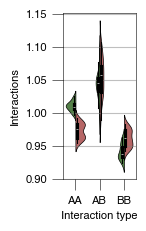

In [67]:
groups_colors = {'HC\no/y': '#4e893f',
                 'SZ\no/y': '#c35959'}

f, axs = plt.subplots(
    figsize=(1.5, 2.35),
    ncols=1,
    nrows=1)


box_plot1=sns.violinplot(data = pd_interactions, y = 'Interactions', x = 'Interaction type', palette = groups_colors,linewidth=0.5, linecolor="k", hue="", split=True, ax = axs)#,

axs.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)

pairs = [('HC\no/y', 'SZ\no/y')]

plt.legend().remove() 
plt.tight_layout()

#plt.savefig('picture_results/Saddleplots_corner_interactions_all_glia.svg',bbox_inches='tight')



p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC
o/y vs. SZ
o/y: Mann-Whitney-Wilcoxon test two-sided, P_val:1.390e-09 U_stat=6.250e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC
o/y vs. SZ
o/y: Mann-Whitney-Wilcoxon test two-sided, P_val:2.687e-01 U_stat=2.550e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC
o/y vs. SZ
o/y: Mann-Whitney-Wilcoxon test two-sided, P_val:1.372e-05 U_stat=8.800e+01


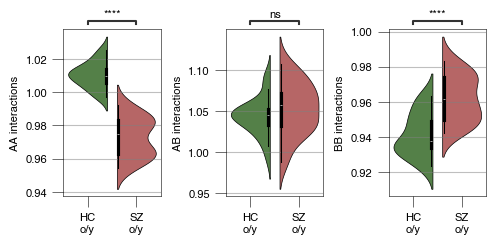

In [68]:
pd_aa_hc = pd.DataFrame({'AA interactions':aa_int_hc})
pd_aa_sz = pd.DataFrame({'AA interactions':aa_int_sz})

pd_aa_hc[''] = 'HC\no/y'
pd_aa_sz[''] = 'SZ\no/y'
pd_aa = pd.concat([pd_aa_hc, pd_aa_sz], axis = 0)

pd_ab_hc = pd.DataFrame({'AB interactions':ab_int_hc})
pd_ab_sz = pd.DataFrame({'AB interactions':ab_int_sz})

pd_ab_hc[''] = 'HC\no/y'
pd_ab_sz[''] = 'SZ\no/y'
pd_ab = pd.concat([pd_ab_hc, pd_ab_sz], axis = 0)

pd_bb_hc = pd.DataFrame({'BB interactions':bb_int_hc})
pd_bb_sz = pd.DataFrame({'BB interactions':bb_int_sz})

pd_bb_hc[''] = 'HC\no/y'
pd_bb_sz[''] = 'SZ\no/y'
pd_bb = pd.concat([pd_bb_hc, pd_bb_sz], axis = 0)


f, axs = plt.subplots(
    figsize=(5, 2.5),
    ncols=3,
    nrows=1)


box_plot1=sns.violinplot(data = pd_aa, y = 'AA interactions', x = '', palette = groups_colors,linewidth=0.5, linecolor="k", hue="", split=True, ax = axs[0])#,

axs[0].grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)

pairs = [('HC\no/y', 'SZ\no/y')]

annotator = Annotator(box_plot1, pairs, data=pd_aa, y= 'AA interactions', x= '')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
annotator.apply_and_annotate()




box_plot2=sns.violinplot(data = pd_ab, y = 'AB interactions', x = '', palette = groups_colors,linewidth=0.5, linecolor="k", hue="", split=True, ax = axs[1])#,

axs[1].grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)

pairs = [('HC\no/y', 'SZ\no/y')]

annotator = Annotator(box_plot2, pairs, data=pd_ab, y= 'AB interactions', x= '')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
annotator.apply_and_annotate()




box_plot3=sns.violinplot(data = pd_bb, y = 'BB interactions', x = '', palette = groups_colors,linewidth=0.5, linecolor="k", hue="", split=True, ax = axs[2])#,

axs[2].grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)

pairs = [('HC\no/y', 'SZ\no/y')]

annotator = Annotator(box_plot3, pairs, data=pd_bb, y= 'BB interactions', x= '')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
annotator.apply_and_annotate()

plt.tight_layout()


#plt.savefig('picture_results/Saddleplots_corner_interactions_neuron.svg',bbox_inches='tight')
